In [1]:
import requests
import geopandas as gpd
import pandas as pd
from typing import Final


In [2]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}", verify=False
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory", verify=False
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value

polygon_gdf['Потенциал развития жилой застройки'] = 4

LAND_USE_TO_POTENTIAL_COLUMN: Final[dict[str, str]] = {
    "residential": "Потенциал развития жилой застройки",
    "business":     "Потенциал развития застройки общественно-деловой зоны",
    "recreation":   "Потенциал развития застройки рекреационной зоны",
    "special":      "Потенциал развития застройки зоны специального назначения",
    "industrial":   "Потенциал развития застройки промышленной зоны",
    "agriculture":  "Потенциал развития застройки сельскохозяйственной зоны",
    "transport":    "Потенциал развития застройки транспортной зоны",
}

records = []
for _, row in polygon_gdf.iterrows():
    for ip_type, col_name in LAND_USE_TO_POTENTIAL_COLUMN.items():
        records.append({
            "ip_type":  ip_type,
            "ip_value": row[col_name],
            "geometry": row.geometry
        })

# Создаём новый GeoDataFrame
base_gdf = gpd.GeoDataFrame(records, crs=polygon_gdf.crs)
base_gdf = base_gdf.reset_index(drop=True)
base_gdf



/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  w

,ip_type,ip_value,geometry
0,residential,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
1,business,2.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
2,recreation,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
3,special,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
4,industrial,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
5,agriculture,3.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
6,transport,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."


(np.float64(387426.68513317255),
 np.float64(391261.1686471378),
 np.float64(6642774.223558956),
 np.float64(6645352.796501488))

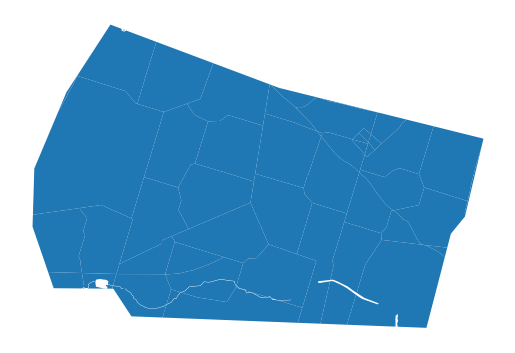

In [3]:
from urbanomy.methods.investment_potential import prepare_investment_input

scenario_blocks = pd.read_pickle('./data/test/blocks_with_price.pickle').to_crs(32636)

polygon_input = prepare_investment_input(
    gdf = scenario_blocks,
    base_gdf = base_gdf,
)

polygon_input.plot().axis('off')


In [4]:
polygon_input.head()


,geometry,land_use,price_pred,site_area,living_area,non_living_area,build_floor_area,share,price_per_sotka,ip_value
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",AGRICULTURE,1.826177e+08,202399.732193,0.000000,12550.416350,12550.416350,0.918180,90226.276851,3.0
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",BUSINESS,2.063089e+08,201529.493481,0.000000,40777.554163,40777.554163,0.938081,102371.585062,2.0
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",TRANSPORT,1.508134e+08,164663.859830,0.000000,24985.657278,24985.657278,0.891381,91588.658404,4.0
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",RESIDENTIAL,4.262998e+08,161571.832511,29356.894977,43211.816923,72568.711901,0.934862,263845.391105,4.0
4,"POLYGON ((388000.75 6643199.606, 388001.306 66...",RESIDENTIAL,3.985893e+04,49.926816,0.678865,1.491128,2.169993,0.132440,79834.708632,4.0


In [5]:
benchmarks_demo = {
    "RESIDENTIAL": {
        "cost_build": 45_000,
        "price_sale": 90_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    "BUSINESS": {
        "cost_build": 55_000,
        "rent_annual": 14_000,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 1300,
    },
    "RECREATION": {
        "cost_build": 20_000,
        "rent_annual": 3_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1000,
    },
    "SPECIAL": {
        "cost_build": 35_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1500,
    },
    "INDUSTRIAL": {
        "cost_build": 38_000,
        "rent_annual": 9_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    "AGRICULTURE": {
        "cost_build": 25_000,
        "rent_annual": 3_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    "TRANSPORT": {
        "cost_build": 18_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [ ]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
gdf_out, summary = an.calculate_investment_metrics(polygon_input)
summary


,land_use,land_area,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,AGRICULTURE,"202,399.73","12,550.42","182,617,742.71","313,760,408.75","496,378,151.46","-265,416,641.08",0.00,1.18,NaN,0.00,3.00,21.36
1,BUSINESS,"201,529.49","40,777.55","206,308,936.85","2,242,765,478.95","2,449,074,415.79","165,411,078.72",0.13,4.50,13.40,37.52,2.00,21.49
2,TRANSPORT,"164,663.86","24,985.66","150,813,420.09","449,741,831.00","600,555,251.09","-127,596,425.21",0.08,2.92,NaN,0.00,4.00,42.73
3,RESIDENTIAL,"161,571.83","72,568.71","426,299,833.40","3,265,592,035.52","3,691,891,868.93","702,811,994.95",0.19,2.76,5.42,69.48,4.00,82.52
4,RESIDENTIAL,49.93,2.17,"39,858.93","97,649.70","137,508.63","-6,095.55",0.10,1.73,NaN,0.00,4.00,42.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,AGRICULTURE,2.67,NaN,"10,758.84",NaN,"10,758.84","-24,244.42",0.06,2.54,NaN,0.00,3.00,21.36
64,TRANSPORT,"4,307.66",688.58,"4,339,395.43","12,394,358.77","16,733,754.20","-3,405,068.15",0.08,2.95,NaN,0.00,4.00,42.73
65,BUSINESS,61.63,13.49,"17,841.16","741,800.00","759,641.16","162,840.91",0.16,5.89,11.09,11.11,2.00,6.37
66,SPECIAL,175.85,60.89,"45,011.39","2,131,233.21","2,176,244.61","192,976.60",0.14,5.98,15.02,4.27,4.00,45.18


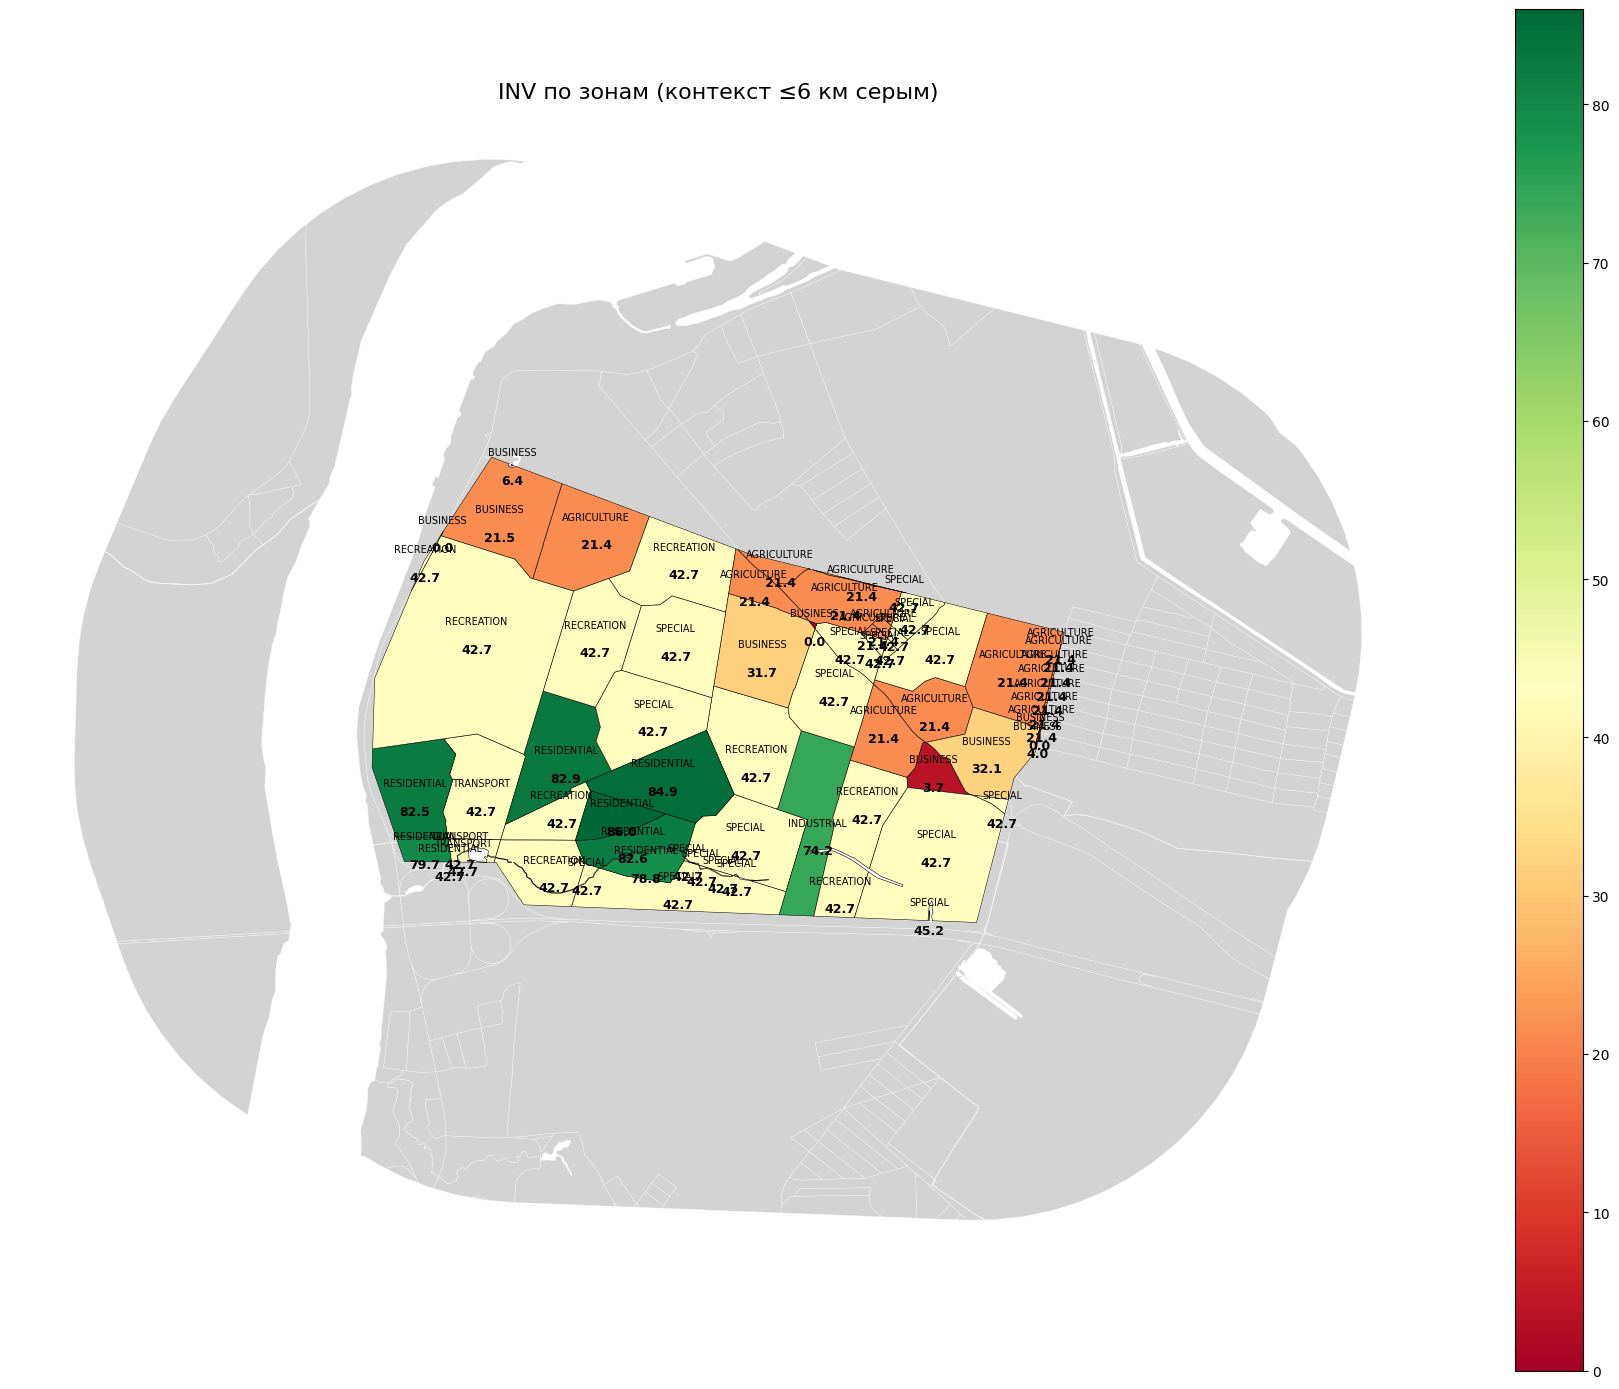

In [8]:
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
import matplotlib.ticker as mticker

def make_buffer_m(gdf, radius_m):
    g = gpd.GeoDataFrame(geometry=[gdf.geometry.union_all()], crs=gdf.crs)
    if g.crs and g.crs.is_geographic:
        utm = g.estimate_utm_crs()
        g = g.to_crs(utm); g['geometry'] = g.buffer(radius_m); g = g.to_crs(scenario_blocks.crs)
    else:
        g['geometry'] = g.buffer(radius_m)
    return g


# Разделяем на сценические и контекст
scn = plot_gdf
ctx = scenario_blocks[~scenario_blocks['is_scn']].copy()

# Буфер вокруг сценических
buf6_gdf = make_buffer_m(scn, 1500)
context_6km = gpd.clip(ctx, buf6_gdf)

# Настройка шкалы
vmin, vmax = scn['INV'].min(), scn['INV'].max()

fig, ax = plt.subplots(figsize=(18, 14))

# Контекст серым
context_6km.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2, zorder=1)

# Сценические цветом
scn.plot(column='INV', cmap='RdYlGn', vmin=vmin, vmax=vmax,
         edgecolor='black', linewidth=0.4, legend=True, ax=ax, zorder=2)

# Подписи
for _, row in scn.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(x, y, row['land_use'], ha='center', va='bottom', fontsize=7,
            color='black', transform=offset_copy(ax.transData, fig=fig, y=6, units='points'), zorder=3)
    ax.text(x, y, f"{row['INV']:.1f}", ha='center', va='top', fontsize=9, fontweight='bold',
            color='black', transform=offset_copy(ax.transData, fig=fig, y=-6, units='points'), zorder=3)

ax.set_title('INV по зонам (контекст ≤6 км серым)', fontsize=16)
ax.axis('off')

# Красивый формат легенды
cbar_ax = fig.axes[-1]
cbar_ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)

plt.tight_layout()
plt.show()


In [9]:
# gdf_out.to_file('./data/test/blocks_investment.geojson', driver='GeoJSON')